In [ ]:
# Run this in a Colab cell
!pip install kagglehub timm torch torchvision scikit-learn matplotlib seaborn --quiet

In [ ]:
import zipfile
import os

# Unzip it
zip_filename = "archive.zip"  # change to your actual zip name
extract_path = "/content/dataset"

with zipfile.ZipFile(zip_filename, 'r') as zip_ref:
    zip_ref.extractall(extract_path)

print("Extracted!")

# Check the folder structure
for item in os.listdir(extract_path):
    print(item)

Extracted!
RAS-Compound-character-dataset


In [ ]:
from pathlib import Path

dataset_path = Path("/content/dataset/RAS-Compound-character-dataset")

for split in dataset_path.iterdir():
    if split.is_dir():
        print(split)
        print(list(split.iterdir())[:5])

/content/dataset/RAS-Compound-character-dataset/test
[PosixPath('/content/dataset/RAS-Compound-character-dataset/test/36'), PosixPath('/content/dataset/RAS-Compound-character-dataset/test/102'), PosixPath('/content/dataset/RAS-Compound-character-dataset/test/98'), PosixPath('/content/dataset/RAS-Compound-character-dataset/test/114'), PosixPath('/content/dataset/RAS-Compound-character-dataset/test/27')]
/content/dataset/RAS-Compound-character-dataset/train
[PosixPath('/content/dataset/RAS-Compound-character-dataset/train/36'), PosixPath('/content/dataset/RAS-Compound-character-dataset/train/102'), PosixPath('/content/dataset/RAS-Compound-character-dataset/train/98'), PosixPath('/content/dataset/RAS-Compound-character-dataset/train/114'), PosixPath('/content/dataset/RAS-Compound-character-dataset/train/27')]


In [ ]:
train_path = dataset_path / "train"

class_dirs = [d for d in train_path.iterdir() if d.is_dir()]

print("Number of classes:", len(class_dirs))

for cls in sorted(class_dirs)[:5]:
    imgs = list(cls.glob("*.png"))
    print(cls.name, len(imgs))

Number of classes: 119
1 58
10 62
100 63
101 63
102 60


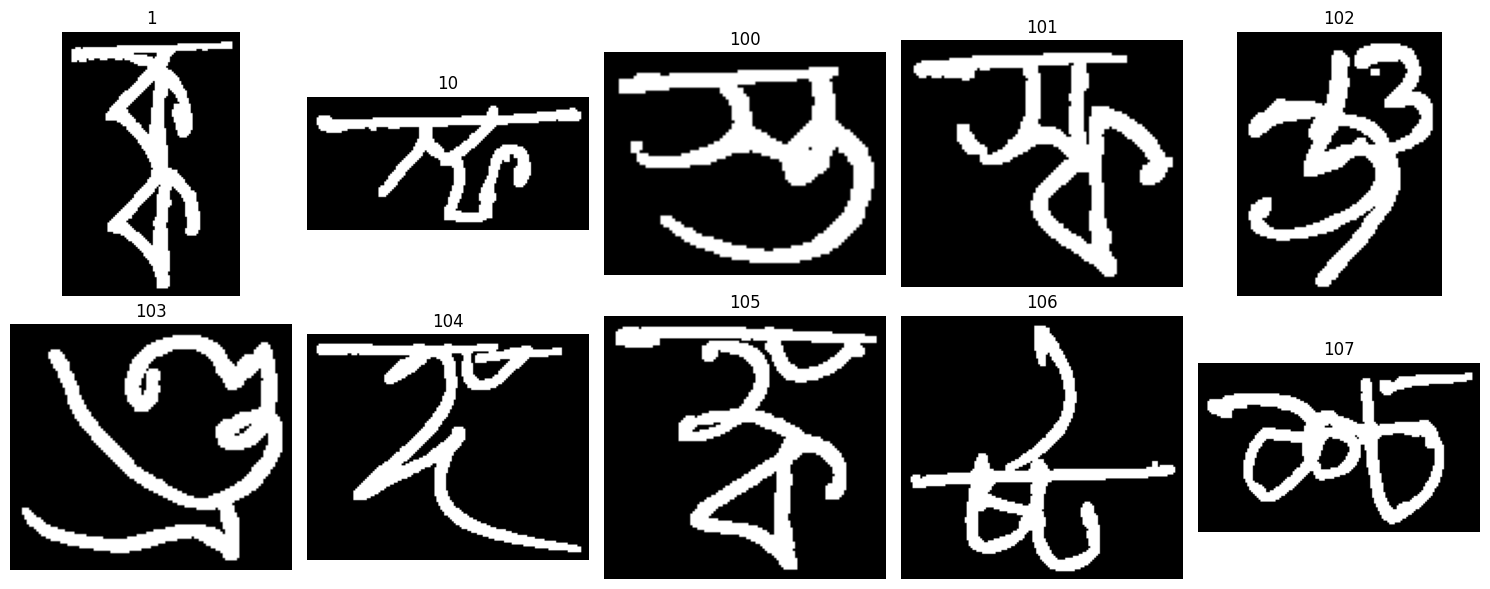

In [ ]:
import matplotlib.pyplot as plt
from PIL import Image

train_path = dataset_path / "train"
class_dirs = sorted([d for d in train_path.iterdir() if d.is_dir()])

fig, axes = plt.subplots(2, 5, figsize=(15, 6))

for ax, cls in zip(axes.flat, class_dirs[:10]):
    imgs = list(cls.glob("*.png"))

    if imgs:
        img = Image.open(imgs[0]).convert("L")
        ax.imshow(img, cmap="gray")
        ax.set_title(cls.name)
        ax.axis("off")

plt.tight_layout()
plt.show()

In [ ]:
import torch
from torch.utils.data import DataLoader, random_split
from torchvision import datasets, transforms

IMG_SIZE = 224  # ViT standard input size
BATCH_SIZE = 32
NUM_WORKERS = 2

train_transforms = transforms.Compose([
    transforms.Grayscale(num_output_channels=3),  # ViT expects 3 channels
    transforms.Resize((IMG_SIZE, IMG_SIZE)),
    transforms.RandomRotation(15),
    transforms.RandomAffine(degrees=0, translate=(0.1, 0.1), shear=5),
    transforms.ColorJitter(brightness=0.3, contrast=0.3),
    transforms.ToTensor(),
    transforms.Normalize(mean=[0.5, 0.5, 0.5], std=[0.5, 0.5, 0.5])
])

val_transforms = transforms.Compose([
    transforms.Grayscale(num_output_channels=3),
    transforms.Resize((IMG_SIZE, IMG_SIZE)),
    transforms.ToTensor(),
    transforms.Normalize(mean=[0.5, 0.5, 0.5], std=[0.5, 0.5, 0.5])
])

# Load datasets for train and test splits separately
train_full_dataset = datasets.ImageFolder(root=str(dataset_path / "train"), transform=train_transforms)
test_dataset = datasets.ImageFolder(root=str(dataset_path / "test"), transform=val_transforms)

class_names = train_full_dataset.classes
NUM_CLASSES = len(class_names)
print(f"Classes: {NUM_CLASSES}")
print(f"Total samples in training set: {len(train_full_dataset)}")
print(f"Total samples in test set: {len(test_dataset)}")

# Split training set into train and validation (80% train, 10% val from original training data)
total_train = len(train_full_dataset)
train_size = int(0.9 * total_train) # 90% of original train for new train + val
val_size = total_train - train_size

train_data, val_data = random_split(
    train_full_dataset, [train_size, val_size],
    generator=torch.Generator().manual_seed(42)
)

# Create DataLoaders
train_loader = DataLoader(train_data, batch_size=BATCH_SIZE, shuffle=True,  num_workers=NUM_WORKERS, pin_memory=True)
val_loader   = DataLoader(val_data,   batch_size=BATCH_SIZE, shuffle=False, num_workers=NUM_WORKERS, pin_memory=True)
test_loader  = DataLoader(test_dataset,  batch_size=BATCH_SIZE, shuffle=False, num_workers=NUM_WORKERS, pin_memory=True)

print(f"Train: {len(train_data)} | Val: {len(val_data)} | Test: {len(test_dataset)}")

Classes: 119
Total samples in training set: 7020
Total samples in test set: 816
Train: 6318 | Val: 702 | Test: 816


In [ ]:
import pandas as pd

mapping_df = pd.read_csv("class_mapping.csv")
id_to_char = dict(zip(mapping_df["class_id"].astype(str), mapping_df["bengali_character"]))
display_names = [id_to_char[c] for c in class_names]

In [ ]:
import timm
import torch.nn as nn

device = torch.device("cuda" if torch.cuda.is_available() else "cpu")
print(f"Using device: {device}")

class BengaliViT(nn.Module):
    def __init__(self, num_classes, pretrained=True):
        super().__init__()
        # Load pretrained ViT-Base/16 (ImageNet pretrained)
        self.vit = timm.create_model(
            "vit_base_patch16_224",
            pretrained=pretrained,
            num_classes=0  # remove classification head
        )
        embed_dim = self.vit.embed_dim  # 768 for ViT-Base

        # Custom classifier head
        self.classifier = nn.Sequential(
            nn.LayerNorm(embed_dim),
            nn.Dropout(p=0.3),
            nn.Linear(embed_dim, 512),
            nn.GELU(),
            nn.Dropout(p=0.2),
            nn.Linear(512, num_classes)
        )

    def forward(self, x):
        features = self.vit(x)    # [B, 768]
        return self.classifier(features)

model = BengaliViT(num_classes=NUM_CLASSES, pretrained=True).to(device)
print(f"Model parameters: {sum(p.numel() for p in model.parameters()):,}")

Using device: cuda


/usr/local/lib/python3.12/dist-packages/huggingface_hub/utils/_auth.py:124: UserWarning: 
The secret `HF_TOKEN` does not exist in your Colab secrets.
To authenticate with the Hugging Face Hub, create a token in your settings tab (https://huggingface.co/settings/tokens), set it as secret in your Google Colab and restart your session.
You will be able to reuse this secret in all of your notebooks.
Please note that authentication is recommended but still optional to access public models or datasets.
  warnings.warn(


model.safetensors:   0%|          | 0.00/346M [00:00<?, ?B/s]

Model parameters: 86,254,967


In [ ]:
from torch.optim import AdamW
from torch.optim.lr_scheduler import CosineAnnealingLR

EPOCHS = 30
LR = 3e-4
WEIGHT_DECAY = 1e-4

criterion = nn.CrossEntropyLoss(label_smoothing=0.1)

# Different LR for backbone vs head (fine-tuning strategy)
optimizer = AdamW([
    {"params": model.vit.parameters(),        "lr": LR * 0.1},  # lower LR for pretrained backbone
    {"params": model.classifier.parameters(), "lr": LR}          # higher LR for new head
], weight_decay=WEIGHT_DECAY)

scheduler = CosineAnnealingLR(optimizer, T_max=EPOCHS, eta_min=1e-6)

In [ ]:
import time
from copy import deepcopy

def train_epoch(model, loader, optimizer, criterion, device):
    model.train()
    total_loss, correct, total = 0, 0, 0
    for imgs, labels in loader:
        imgs, labels = imgs.to(device), labels.to(device)
        optimizer.zero_grad()
        outputs = model(imgs)
        loss = criterion(outputs, labels)
        loss.backward()
        torch.nn.utils.clip_grad_norm_(model.parameters(), max_norm=1.0)
        optimizer.step()
        total_loss += loss.item() * imgs.size(0)
        correct += (outputs.argmax(1) == labels).sum().item()
        total += imgs.size(0)
    return total_loss / total, correct / total

def eval_epoch(model, loader, criterion, device):
    model.eval()
    total_loss, correct, total = 0, 0, 0
    with torch.no_grad():
        for imgs, labels in loader:
            imgs, labels = imgs.to(device), labels.to(device)
            outputs = model(imgs)
            loss = criterion(outputs, labels)
            total_loss += loss.item() * imgs.size(0)
            correct += (outputs.argmax(1) == labels).sum().item()
            total += imgs.size(0)
    return total_loss / total, correct / total

# --- Main training ---
best_val_acc = 0.0
best_model_wts = None
history = {"train_loss": [], "val_loss": [], "train_acc": [], "val_acc": []}

for epoch in range(1, EPOCHS + 1):
    t0 = time.time()
    tr_loss, tr_acc = train_epoch(model, train_loader, optimizer, criterion, device)
    va_loss, va_acc = eval_epoch(model, val_loader, criterion, device)
    scheduler.step()

    history["train_loss"].append(tr_loss)
    history["val_loss"].append(va_loss)
    history["train_acc"].append(tr_acc)
    history["val_acc"].append(va_acc)

    if va_acc > best_val_acc:
        best_val_acc = va_acc
        best_model_wts = deepcopy(model.state_dict())
        torch.save(best_model_wts, "best_bengali_vit.pth")

    print(f"Epoch [{epoch:02d}/{EPOCHS}] "
          f"Train Loss: {tr_loss:.4f} Acc: {tr_acc:.4f} | "
          f"Val Loss: {va_loss:.4f} Acc: {va_acc:.4f} | "
          f"Time: {time.time()-t0:.1f}s | Best Val: {best_val_acc:.4f}")

print(f"\nBest Validation Accuracy: {best_val_acc:.4f}")

Epoch [01/30] Train Loss: 2.4648 Acc: 0.6299 | Val Loss: 0.9789 Acc: 0.9872 | Time: 242.0s | Best Val: 0.9872
Epoch [02/30] Train Loss: 0.9498 Acc: 0.9888 | Val Loss: 0.8940 Acc: 0.9886 | Time: 249.7s | Best Val: 0.9886
Epoch [03/30] Train Loss: 0.8857 Acc: 0.9956 | Val Loss: 0.8618 Acc: 0.9943 | Time: 249.8s | Best Val: 0.9943
Epoch [04/30] Train Loss: 0.8587 Acc: 0.9978 | Val Loss: 0.8422 Acc: 0.9972 | Time: 249.6s | Best Val: 0.9972
Epoch [05/30] Train Loss: 0.8465 Acc: 0.9987 | Val Loss: 0.8391 Acc: 0.9957 | Time: 248.3s | Best Val: 0.9972
Epoch [06/30] Train Loss: 0.8362 Acc: 0.9997 | Val Loss: 0.8373 Acc: 0.9957 | Time: 248.9s | Best Val: 0.9972
Epoch [07/30] Train Loss: 0.8314 Acc: 0.9998 | Val Loss: 0.8379 Acc: 0.9957 | Time: 249.3s | Best Val: 0.9972
Epoch [08/30] Train Loss: 0.8291 Acc: 0.9992 | Val Loss: 0.8325 Acc: 0.9943 | Time: 249.3s | Best Val: 0.9972
Epoch [09/30] Train Loss: 0.8249 Acc: 0.9998 | Val Loss: 0.8323 Acc: 0.9957 | Time: 248.9s | Best Val: 0.9972


In [ ]:
import numpy as np
from sklearn.metrics import classification_report, confusion_matrix
import seaborn as sns

model.load_state_dict(best_model_wts)
model.eval()

y_true, y_pred = [], []
with torch.no_grad():
    for imgs, labels in test_loader:
        imgs = imgs.to(device)
        outputs = model(imgs)
        y_pred.extend(outputs.argmax(1).cpu().numpy())
        y_true.extend(labels.numpy())

y_true, y_pred = np.array(y_true), np.array(y_pred)
test_acc = (y_true == y_pred).mean()
cer = 1 - test_acc  # single-character samples: CER == top-1 error rate
print(f"Test Accuracy: {test_acc:.4f}")
print(f"CER          : {cer:.4f}\n")
print(classification_report(y_true, y_pred, target_names=display_names, zero_division=0))

cm = confusion_matrix(y_true, y_pred)
plt.figure(figsize=(14, 12))
sns.heatmap(cm, cmap="Blues", xticklabels=display_names, yticklabels=display_names)
plt.xlabel("Predicted")
plt.ylabel("True")
plt.title(f"Confusion Matrix (CER: {cer:.4f})")
plt.tight_layout()
plt.show()

In [ ]:
torch.save({
    "state_dict": best_model_wts,
    "class_names": class_names,
    "display_names": display_names,
    "img_size": IMG_SIZE,
}, "best_bengali_vit.pth")
print("Saved best_bengali_vit.pth (state_dict + class_names + display_names + img_size)")